In [2]:
import numpy as np
import pandas as pd
import scipy.sparse as sps
import matplotlib.pyplot as pyplot
%matplotlib inline
from Evaluation.Evaluator import EvaluatorHoldout
from Data_manager.split_functions.split_train_validation_random_holdout import split_train_in_two_percentage_global_sample
from Recommenders.Similarity.Compute_Similarity_Python import Compute_Similarity_Python

In [3]:
df2 = pd.read_csv('data/sample_submission.csv')

print(df2.head())
print(df2.shape)

   user_id                                          item_list
0        0  0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19
1        1  0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19
2        2  0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19
3        3  0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19
4        4  0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19
(27095, 2)


In [4]:
df = pd.read_csv('data/data_target_users_test.csv')

print(df.head())
print(df.shape)

   user_id
0        0
1        1
2        2
3        3
4        4
(27095, 1)


In [5]:
df = pd.read_csv('data/data_train.csv')

print(df.head())
print(df.shape)

   row  col
0    0   44
1    0  227
2    0  236
3    0  247
4    0  325
(3043058, 2)


In [6]:
URM_all_dataframe=df
URM_all_dataframe.columns = ["UserID", "ItemID"]
URM_all_dataframe['hasInteraction'] = 1
print(URM_all_dataframe.head())
print(URM_all_dataframe.shape)

   UserID  ItemID  hasInteraction
0       0      44               1
1       0     227               1
2       0     236               1
3       0     247               1
4       0     325               1
(3043058, 3)


In [7]:
def get_all_users_interactions(df):
    """
    Returns interaction counts for all users as a DataFrame

    Parameters:
    df (DataFrame): The input DataFrame

    Returns:
    DataFrame: DataFrame with UserID and InteractionCount for all users
    """
    interaction_counts = df.groupby('UserID')['hasInteraction'].sum().reset_index()
    interaction_counts.columns = ['UserID', 'InteractionCount']
    return interaction_counts

# Usage
result = get_all_users_interactions(df)
print(result)

       UserID  InteractionCount
0           0                96
1           1                49
2           2                60
3           3                62
4           4               119
...       ...               ...
27090   27090              1292
27091   27091               144
27092   27092                39
27093   27093                53
27094   27094               314

[27095 rows x 2 columns]


In [15]:
def filter_high_interaction_users(df, threshold=1000):
    """
    Filters users with interaction count greater than the threshold

    Parameters:
    df (DataFrame): The input DataFrame
    threshold (int): Minimum interaction count to filter (default: 1000)

    Returns:
    DataFrame: DataFrame with UserID and InteractionCount for users with interactions > threshold
    """
    # Get all users' interaction counts
    interaction_counts = get_all_users_interactions(df)
    # Filter users with interaction count > threshold
    high_interaction_users = interaction_counts[interaction_counts['InteractionCount'] < threshold]

    return high_interaction_users

# Usage
high_interaction_users = filter_high_interaction_users(df, threshold=20)
print("Users with more than 1000 interactions:")
print(high_interaction_users)

Users with more than 1000 interactions:
       UserID  InteractionCount
7           7                18
125       125                18
166       166                18
199       199                18
239       239                18
...       ...               ...
26959   26959                18
26966   26966                19
26995   26995                16
27029   27029                16
27069   27069                19

[752 rows x 2 columns]


In [9]:
def plot_ordered_interactions(df):
    """
    Creates an ordered bar plot using pyplot
    """
    # Get and sort the data
    result = get_all_users_interactions(df)
    result_sorted = result.sort_values('InteractionCount', ascending=False)

    # Create plot using pyplot
    pyplot.figure(figsize=(12, 6))
    pyplot.bar(result_sorted['UserID'].astype(str), result_sorted['InteractionCount'],
               color='skyblue', edgecolor='navy', alpha=0.7)

    # Customize the plot
    pyplot.title('User Interaction Counts (Ordered by Interactions)', fontsize=16, fontweight='bold')
    pyplot.xlabel('User ID', fontsize=12)
    pyplot.ylabel('Number of Interactions', fontsize=12)
    pyplot.grid(axis='y', alpha=0.3)
    pyplot.xticks(rotation=45)

    pyplot.tight_layout()
    pyplot.show()

    return result_sorted

# Usage
sorted_result = plot_ordered_interactions(df)

KeyboardInterrupt: 

In [8]:
URM_all = sps.csr_matrix((URM_all_dataframe['hasInteraction'].values,
                         (URM_all_dataframe['UserID'].values, URM_all_dataframe['ItemID'].values)))

In [9]:
URM_train, URM_test = split_train_in_two_percentage_global_sample(URM_all, train_percentage = 0.80)
URM_train, URM_validation = split_train_in_two_percentage_global_sample(URM_train, train_percentage = 0.80)

evaluator_validation = EvaluatorHoldout(URM_validation, cutoff_list=[10])
evaluator_test = EvaluatorHoldout(URM_test, cutoff_list=[10])

print(URM_test.shape)

EvaluatorHoldout: Ignoring 89 ( 0.3%) Users that have less than 1 test interactions
EvaluatorHoldout: Ignoring 34 ( 0.1%) Users that have less than 1 test interactions
(27095, 6969)


In [10]:
item_id = 80
shrink = 10

numerator_vector = URM_train.T[item_id].dot(URM_train).toarray().ravel()
numerator_vector

array([0., 1., 0., ..., 0., 1., 1.])

In [11]:
item_norms = np.sqrt(np.array(URM_train.power(2).sum(axis=0))).ravel()
denominator_vector = item_norms[item_id] * item_norms + shrink + 1e-6

similarity_vector = numerator_vector/denominator_vector

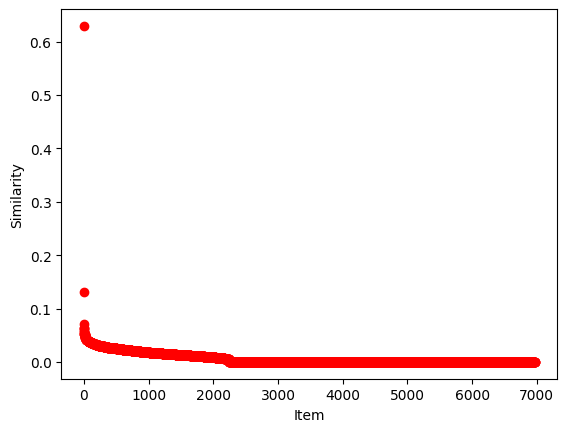

In [12]:
sorted_item_indices = np.argsort(-similarity_vector)

pyplot.plot(similarity_vector[sorted_item_indices], 'ro')
pyplot.ylabel('Similarity')
pyplot.xlabel('Item')
pyplot.show()